<a href="https://colab.research.google.com/github/jenleep/datathonPassosMagicos/blob/main/questoes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparação do ambiente

In [ ]:
# importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ler o arquivo para criar o df
df_fixa = pd.read_csv('/content/base_pede_limpa.csv', sep=None, engine='python')

# 1 Adequação do nível (IAN)

Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?

In [ ]:
# proporcão de nível de defasagem
df_fixa["nivel_defasagem"].value_counts(normalize=True) * 100


,proportion
nivel_defasagem,
moderada,54.191419
em fase,44.323432
severa,1.485149


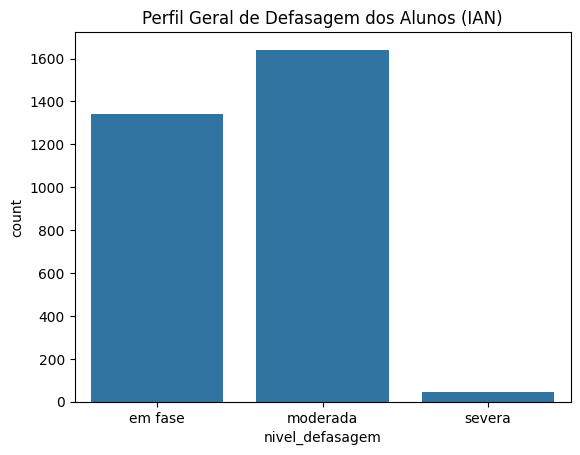

In [ ]:
# plotar
sns.countplot(data=df_base, x="nivel_defasagem", order=["em fase","moderada","severa"])
plt.title("Perfil Geral de Defasagem dos Alunos (IAN)")
plt.show()

In [ ]:
# tabela proporção de defasagem por ano
pd.crosstab(df_fixa["ano"], df_fixa["nivel_defasagem"], normalize="index") * 100


nivel_defasagem,em fase,moderada,severa
ano,,,
2022,30.116279,66.627907,3.255814
2023,45.562130,53.057199,1.380671
2024,53.806228,45.934256,0.259516


In [ ]:
tabela = (
    pd.crosstab(df_fixa["ano"], df_fixa["nivel_defasagem"], normalize="index")
    * 100
)


In [ ]:
ordem = ["em fase", "moderada", "severa"]
tabela = tabela[ordem]


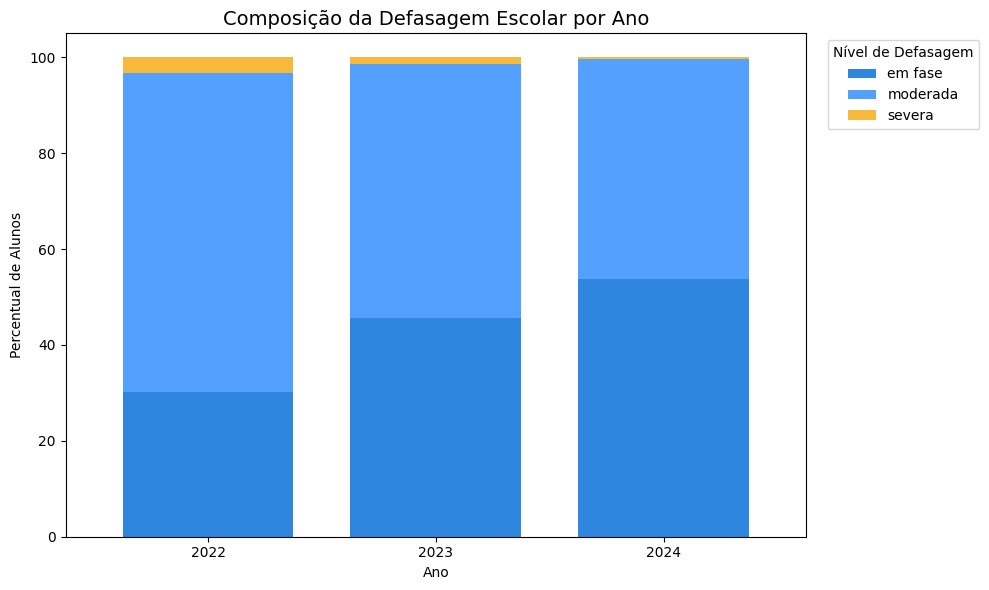

In [ ]:
# plotar
import matplotlib.pyplot as plt

cores = ["#2E86DE", "#54A0FF", "#F6B93B", "#E55039"]

tabela.plot(
    kind="bar",
    stacked=True,
    color=cores,
    figsize=(10,6),
    width=0.75
)

plt.title("Composição da Defasagem Escolar por Ano", fontsize=14)
plt.xlabel("Ano")
plt.ylabel("Percentual de Alunos")
plt.legend(title="Nível de Defasagem", bbox_to_anchor=(1.02,1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



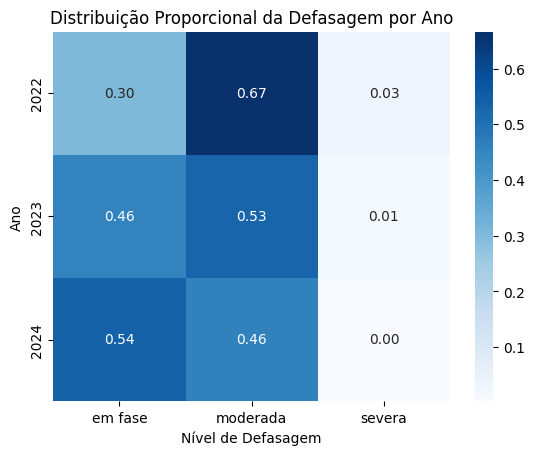

In [ ]:
import seaborn as sns

heat = pd.crosstab(df_fixa["ano"], df_fixa["nivel_defasagem"], normalize="index")

sns.heatmap(heat, annot=True, cmap="Blues", fmt=".2f")

plt.title("Distribuição Proporcional da Defasagem por Ano")
plt.xlabel("Nível de Defasagem")
plt.ylabel("Ano")
plt.show()


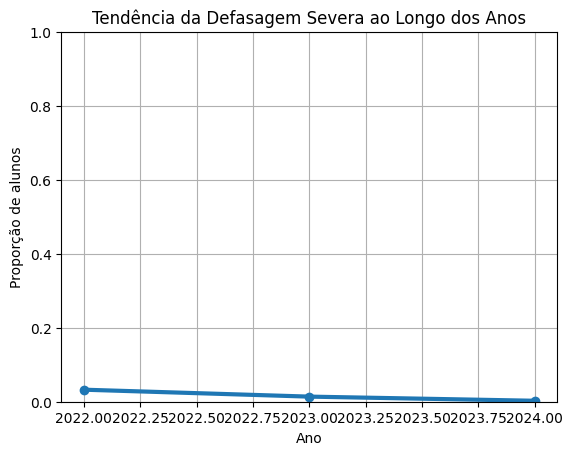

In [ ]:
severa = (
    df_fixa[df_fixa["nivel_defasagem"]=="severa"]
    .groupby("ano")
    .size()
    /
    df_fixa.groupby("ano").size()
)

severa.plot(marker="o", linewidth=3)

plt.title("Tendência da Defasagem Severa ao Longo dos Anos")
plt.ylabel("Proporção de alunos")
plt.xlabel("Ano")
plt.ylim(0,1)
plt.grid()
plt.show()


## sankey

In [ ]:
# Detectando automaticamente o nome da coluna de ID (que pode conter caracteres invisíveis como \ufeff)
id_col = [c for c in df_fixa.columns if 'id_aluno' in c][0]

print(f"Coluna de ID detectada: {id_col}")

# Agora a operação funcionará corretamente
df_fixa[id_col].value_counts().head()

Coluna de ID detectada: ﻿id_aluno


,count
﻿id_aluno,
RA-96,3
RA-94,3
RA-93,3
RA-92,3
RA-91,3


In [ ]:
# Recriando df_sankey com a coluna 'ian' incluída
df_sankey = df_fixa[[id_col, "ano", "nivel_defasagem", "ian"]].copy()
df_sankey = df_sankey.sort_values([id_col, "ano"])

In [ ]:
df_sankey["nivel_prox"] = df_sankey.groupby(id_col)["nivel_defasagem"].shift(-1)
df_sankey["ano_prox"] = df_sankey.groupby(id_col)["ano"].shift(-1)

In [ ]:
df_sankey = df_sankey.dropna()


In [ ]:
fluxo = (
    df_sankey
    .groupby(["nivel_defasagem","nivel_prox"])
    .size()
    .reset_index(name="quantidade")
)

fluxo


,nivel_defasagem,nivel_prox,quantidade
0,em fase,em fase,416
1,em fase,moderada,144
2,moderada,em fase,276
3,moderada,moderada,512
4,moderada,severa,5
5,severa,em fase,2
6,severa,moderada,9
7,severa,severa,5


In [ ]:
df_sankey["origem"] = df_sankey["ano"].astype(str) + " - " + df_sankey["nivel_defasagem"]
df_sankey["destino"] = df_sankey["ano_prox"].astype(str) + " - " + df_sankey["nivel_prox"]


In [ ]:
fluxo = (
    df_sankey
    .groupby(["origem","destino"])
    .size()
    .reset_index(name="quantidade")
)


In [ ]:
import plotly.graph_objects as go

labels = list(pd.concat([fluxo["origem"], fluxo["destino"]]).unique())
label_dict = {label:i for i,label in enumerate(labels)}

source = fluxo["origem"].map(label_dict)
target = fluxo["destino"].map(label_dict)
value = fluxo["quantidade"]


import plotly.graph_objects as go

fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=25,
        thickness=20,
        label=labels
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    )
)])

fig.update_layout(title_text="Mudança de Nível Educacional dos Alunos", font_size=12)
fig.show()



## Perfil de entrada

In [ ]:
primeiro_ano = (
    df_fixa
    .sort_values("ano")
    .groupby(id_col)
    .first()
)

primeiro_ano["nivel_defasagem"].value_counts(normalize=True) * 100

,proportion
nivel_defasagem,
moderada,58.819988
em fase,39.072848
severa,2.107164


In [ ]:
pd.crosstab(df_fixa["fase"], df_fixa["nivel_defasagem"], normalize="index")*100


nivel_defasagem,em fase,moderada,severa
fase,,,
0,37.601297,62.074554,0.324149
1,22.727273,76.545455,0.727273
2,43.703704,55.740741,0.555556
3,59.266802,37.067210,3.665988
4,44.210526,51.228070,4.561404
5,37.333333,60.444444,2.222222
6,32.894737,67.105263,0.000000
7,72.839506,27.160494,0.000000
8,100.000000,0.000000,0.000000


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar dados para o modelo usando df_fixa
# Codificar variáveis categóricas
df_model = df_fixa.copy()
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include=['object', 'bool']).columns.tolist()
id_col_actual = [c for c in df_model.columns if 'id_aluno' in c][0]
cat_cols = [c for c in cat_cols if c != id_col_actual]
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# 2. PCA
columns_pca = ['fase', 'ano_ingresso', 'ipv', 'ian', 'ipp', 'matematica', 'portugues', 'defasagem']
X_pca_input = df_model[columns_pca].fillna(df_model[columns_pca].mean())
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_pca_input)

pca_final = PCA(n_components=4)
X_pca_5d = pca_final.fit_transform(X_scaled_pca)

# 3. Treinar Modelo (RF)
y = df_model['piorou_defasagem'].values
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_pca_5d, y)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_balanced, y_balanced)

# 4. Calcular Probabilidades e Exibir
probabilidades = rf_model.predict_proba(X_pca_5d)[:, 1]
df_fixa['probabilidade_piora'] = probabilidades

print("--- Alunos com Maior Risco de Aumento de Defasagem ---")
ranking_risco = df_fixa[[id_col_actual, 'ano', 'piorou_defasagem', 'probabilidade_piora']].sort_values(by='probabilidade_piora', ascending=False)
display(ranking_risco.head(10))

plt.figure(figsize=(10, 5))
sns.histplot(df_fixa['probabilidade_piora'], bins=25, kde=True, color='darkorange')
plt.title('Distribuição do Risco de Piora na Defasagem')
plt.show()

KeyError: 'piorou_defasagem'

In [ ]:
persistentes = df_sankey[
    (df_sankey["nivel_defasagem"] == "severa") &
    (df_sankey["nivel_prox"] == "severa")
]

# Usando id_col para evitar o KeyError
print(f"Quantidade de alunos com defasagem severa persistente: {persistentes[id_col].nunique()}")

In [ ]:
print(persistentes)

## numérico

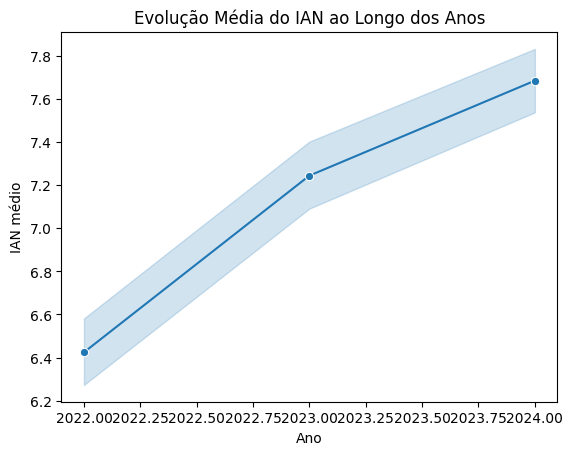

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=df_fixa, x="ano", y="ian", estimator="mean", marker="o")
plt.title("Evolução Média do IAN ao Longo dos Anos")
plt.ylabel("IAN médio")
plt.xlabel("Ano")
plt.show()


In [ ]:
# Calculando o IAN do próximo ano e a diferença (delta)
df_sankey["ian_prox"] = df_sankey.groupby(id_col)["ian"].shift(-1)
df_sankey["delta_ian"] = df_sankey["ian_prox"] - df_sankey["ian"]

print("--- Estatísticas da evolução do IAN (Delta) ---")
display(df_sankey["delta_ian"].describe())

--- Estatísticas da evolução do IAN (Delta) ---


,delta_ian
count,468.000000
mean,0.486111
std,2.696520
min,-5.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,7.500000


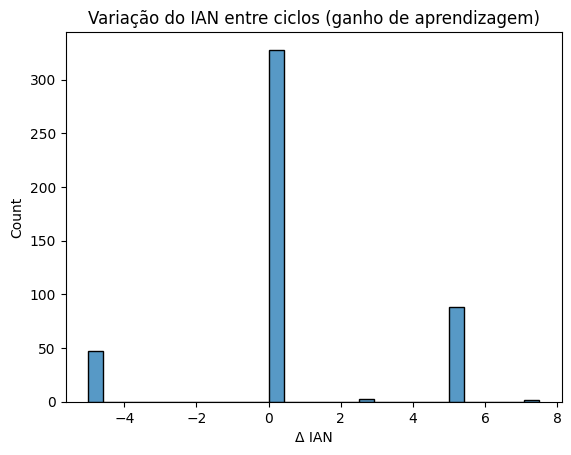

In [ ]:
sns.histplot(df_sankey["delta_ian"], bins=30)
plt.title("Variação do IAN entre ciclos (ganho de aprendizagem)")
plt.xlabel("Δ IAN")
plt.show()


# 2 Desempenho acadêmico (IDA)

O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

In [ ]:
# 2. Analysis of Academic Performance (IDA)

# Calculate mean IDA by year and phase
ida_evolution = df_fixa.groupby(['ano', 'fase'])['ida'].mean().reset_index()

# Create a pivot table for trend comparison
ida_pivot = ida_evolution.pivot(index='fase', columns='ano', values='ida')

print('--- Mean Academic Performance (IDA) Evolution ---')
display(ida_pivot)

# Visualization of Trends
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_fixa, x='fase', y='ida', hue='ano', marker='s')
plt.title('Evolution of Academic Performance (IDA) per Phase and Year')
plt.ylabel('Mean IDA')
plt.xlabel('Phase')
plt.xticks(range(int(df_fixa['fase'].min()), int(df_fixa['fase'].max()) + 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Year')
plt.show()

# Summary calculation
overall_yearly_mean = df_fixa.groupby('ano')['ida'].mean()
print('\nOverall Mean IDA by Year:')
print(overall_yearly_mean)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=df_fixa, x="ano", y="ida", estimator="mean", marker="o")
plt.title("Evolução do Desempenho Acadêmico Médio (IDA) por Ano")
plt.ylabel("IDA médio")
plt.xlabel("Ano")
plt.show()


In [ ]:
sns.boxplot(data=df_fixa, x="ano", y="ida")
plt.title("Distribuição do IDA por Ano")
plt.show()


In [ ]:
sns.boxplot(data=df_fixa, x="fase", y="ida",)

plt.title("IDA ao Longo das Fases do Programa")
plt.xticks(rotation=20)
plt.show()


In [ ]:
df_ida = df_fixa.sort_values([id_col, "ano"])

df_ida["ida_prox"] = df_ida.groupby(id_col)["ida"].shift(-1)
df_ida["delta_ida"] = df_ida["ida_prox"] - df_ida["ida"]

df_ida["delta_ida"].describe()

In [ ]:
sns.histplot(df_ida["delta_ida"].dropna(), bins=30)
plt.title("Ganho Individual de Desempenho Acadêmico (ΔIDA)")
plt.xlabel("Variação do IDA")
plt.show()


# 3 Engajamento nas atividades (IEG)

O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

count    3030.000000
mean        7.918565
std         2.136268
min         0.000000
25%         7.200000
50%         8.500000
75%         9.400000
max        10.000000
Name: ieg, dtype: float64


<Axes: xlabel='ieg', ylabel='Count'>

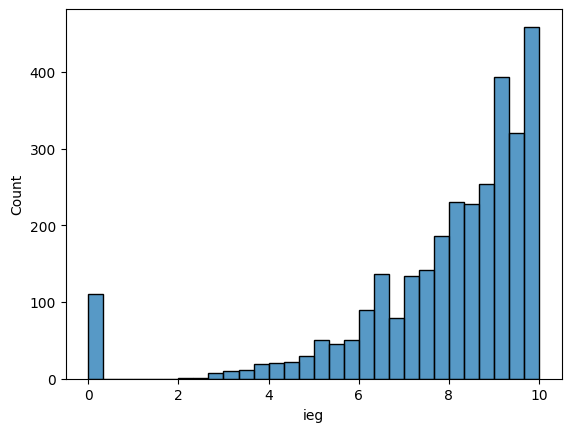

In [ ]:
print(df_fixa["ieg"].describe())
sns.histplot(df_fixa["ieg"], bins=30)


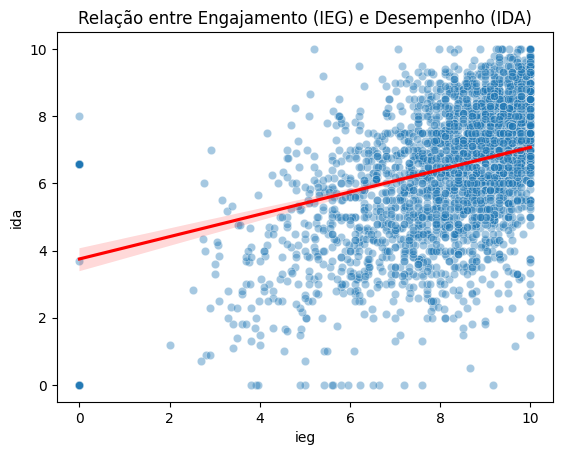

In [ ]:
sns.scatterplot(data=df_fixa, x="ieg", y="ida", alpha=0.4)
sns.regplot(data=df_fixa, x="ieg", y="ida", scatter=False, color="red")
plt.title("Relação entre Engajamento (IEG) e Desempenho (IDA)")
plt.show()


In [ ]:
df_fixa[["ieg","ida"]].corr()


,ieg,ida
ieg,1.000000,0.373369
ida,0.373369,1.000000


In [ ]:
df_fixa["nivel_engajamento"] = pd.qcut(df_fixa["ieg"], 3,
                                       labels=["Baixo","Médio","Alto"])


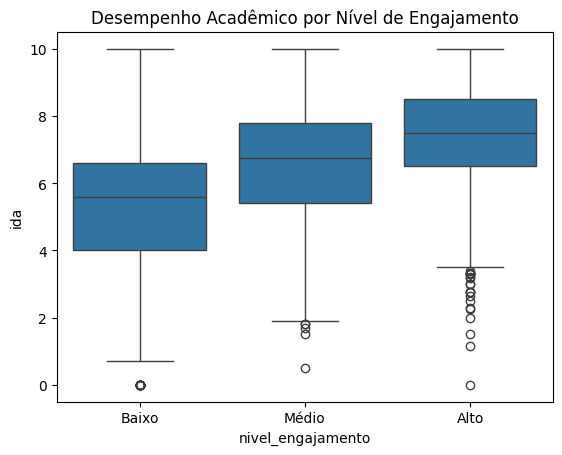

In [ ]:
sns.boxplot(data=df_fixa, x="nivel_engajamento", y="ida")
plt.title("Desempenho Acadêmico por Nível de Engajamento")
plt.show()


In [ ]:
df_fixa.groupby("nivel_engajamento")["ipv"].mean()


/tmp/ipython-input-3991470743.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,ipv
nivel_engajamento,
Baixo,6.812488
Médio,7.605651
Alto,8.144207


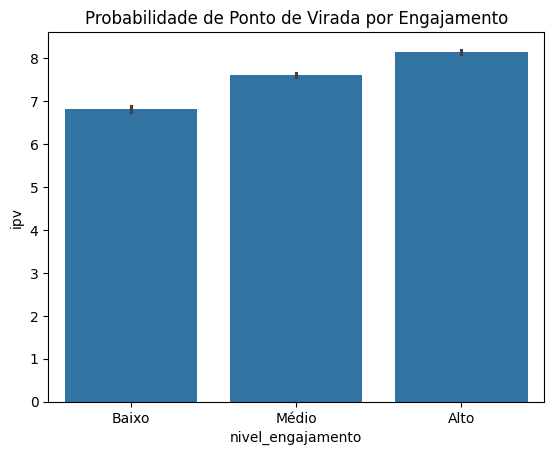

In [ ]:
sns.barplot(data=df_fixa, x="nivel_engajamento", y="ipv")
plt.title("Probabilidade de Ponto de Virada por Engajamento")
plt.show()


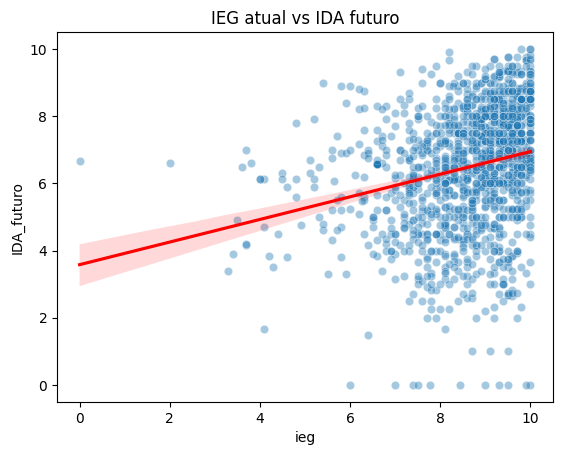

In [ ]:
df_fixa = df_fixa.sort_values([id_col, "ano"])

df_fixa["IDA_futuro"] = df_fixa.groupby(id_col)["ida"].shift(-1)

sns.scatterplot(data=df_fixa, x="ieg", y="IDA_futuro", alpha=0.4)
sns.regplot(data=df_fixa, x="ieg", y="IDA_futuro", scatter=False, color="red")
plt.title("IEG atual vs IDA futuro")
plt.show()

Os resultados indicam relação positiva entre engajamento e desempenho acadêmico. Alunos com maiores níveis de IEG apresentam, em média, melhores valores de IDA e maior probabilidade de atingir o ponto de virada (IPV). A análise longitudinal também sugere efeito antecipado, no qual níveis mais altos de engajamento estão associados a melhor desempenho em períodos posteriores. Esses achados indicam que o engajamento não é apenas consequência do bom desempenho, mas um fator relevante para a evolução educacional do aluno.


# 4 Autoavaliação (IAA)

As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

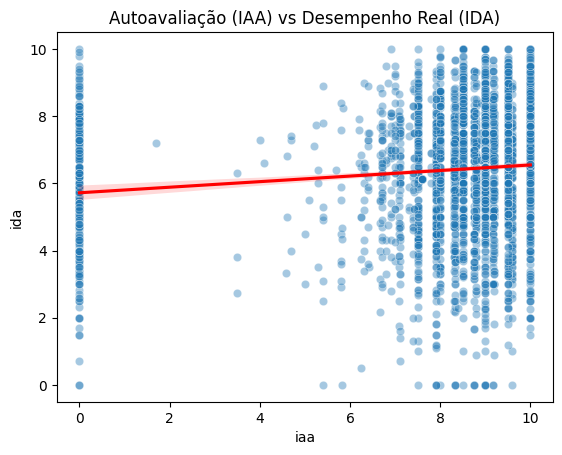

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df_fixa, x="iaa", y="ida", alpha=0.4)
sns.regplot(data=df_fixa, x="iaa", y="ida", scatter=False, color="red")
plt.title("Autoavaliação (IAA) vs Desempenho Real (IDA)")
plt.show()


In [ ]:
df_fixa[["iaa","ida"]].corr()


,iaa,ida
iaa,1.000000,0.112479
ida,0.112479,1.000000


In [ ]:
df_fixa["percepcao"] = pd.qcut(df_fixa["iaa"], 3,
                               labels=["Baixa","Média","Alta"])


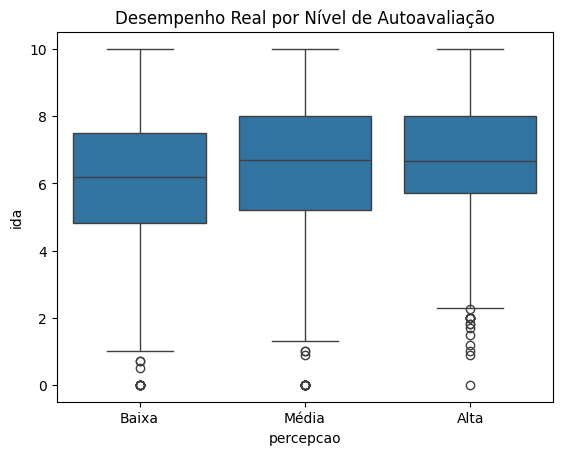

In [ ]:
sns.boxplot(data=df_fixa, x="percepcao", y="ida")
plt.title("Desempenho Real por Nível de Autoavaliação")
plt.show()


In [ ]:
df_fixa["distorcao"] = df_fixa["iaa"] - df_fixa["ida"]


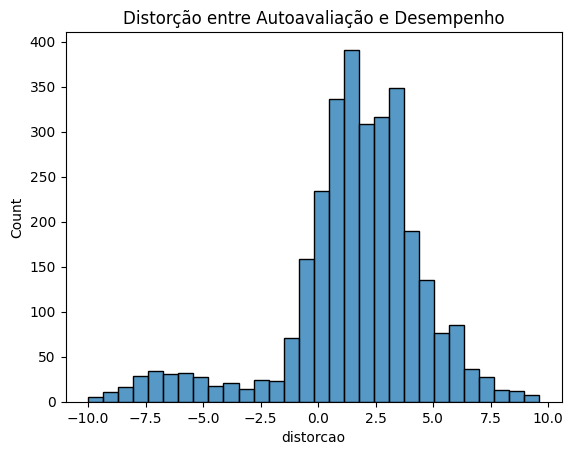

In [ ]:
sns.histplot(df_fixa["distorcao"], bins=30)
plt.title("Distorção entre Autoavaliação e Desempenho")
plt.show()


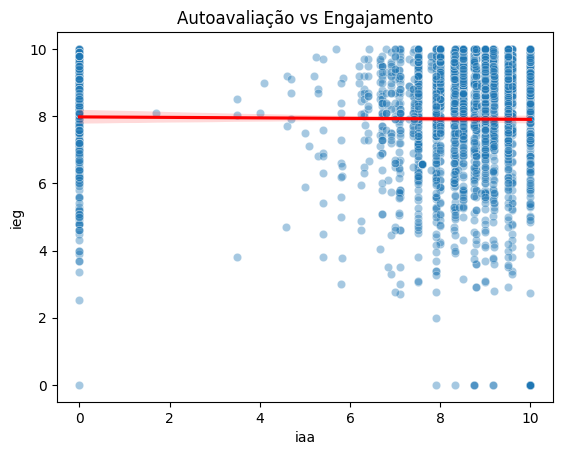

,iaa,ieg
iaa,1.000000,-0.008849
ieg,-0.008849,1.000000


In [ ]:
sns.scatterplot(data=df_fixa, x="iaa", y="ieg", alpha=0.4)
sns.regplot(data=df_fixa, x="iaa", y="ieg", scatter=False, color="red")
plt.title("Autoavaliação vs Engajamento")
plt.show()

df_fixa[["iaa","ieg"]].corr()


In [ ]:
risco_invisivel = df_fixa[
    (df_fixa["iaa"] > df_fixa["iaa"].quantile(0.75)) &
    (df_fixa["ida"] < df_fixa["ida"].quantile(0.25))
]

# Usando id_col para evitar o KeyError
risco_invisivel[id_col].nunique()

113

A relação entre autoavaliação e desempenho real mostra correlação moderada, indicando que parte dos alunos possui percepção adequada sobre seu desempenho acadêmico. Entretanto, observa-se a existência de distorções relevantes: um grupo de alunos apresenta baixa autoavaliação mesmo com bom desempenho, sugerindo insegurança acadêmica, enquanto outro superestima seu desempenho, o que pode reduzir a busca por apoio pedagógico. A autoavaliação também apresenta relação positiva com o engajamento, indicando que a percepção de competência influencia a participação nas atividades. Esses resultados sugerem a necessidade de intervenções psicopedagógicas voltadas ao desenvolvimento de autoeficácia e consciência de aprendizagem.


# 5 Aspectos psicossociais (IPS)

Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

<Axes: xlabel='ips', ylabel='Count'>

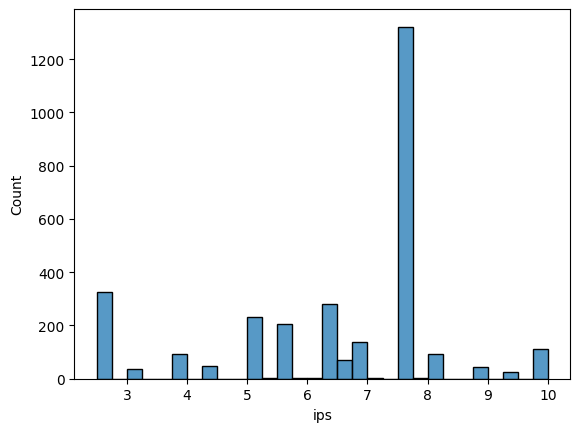

In [ ]:
df_fixa["ips"].describe()
sns.histplot(df_fixa["ips"], bins=30)


In [ ]:
df_fixa["ips"].describe()


,ips
count,3030.000000
mean,6.418347
std,1.865808
min,2.500000
25%,5.600000
50%,7.500000
75%,7.510000
max,10.000000


In [ ]:
df_fixa = df_fixa.sort_values([id_col, "ano"])

df_fixa["IDA_futuro"] = df_fixa.groupby(id_col)["ida"].shift(-1)
df_fixa["IEG_futuro"] = df_fixa.groupby(id_col)["ieg"].shift(-1)

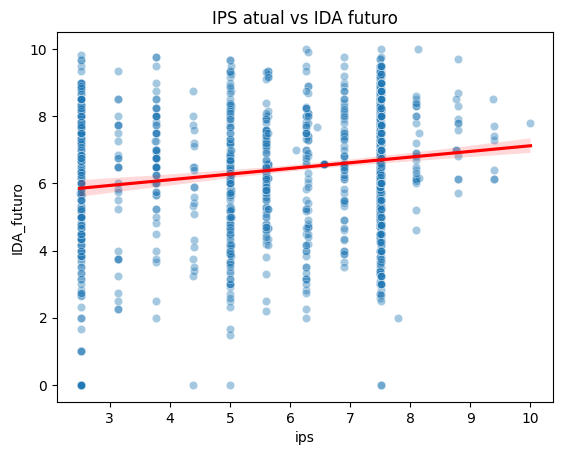

,ips,IDA_futuro
ips,1.000000,0.175503
IDA_futuro,0.175503,1.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df_fixa, x="ips", y="IDA_futuro", alpha=0.4)
sns.regplot(data=df_fixa, x="ips", y="IDA_futuro", scatter=False, color="red")
plt.title("IPS atual vs IDA futuro")
plt.show()

df_fixa[["ips","IDA_futuro"]].corr()


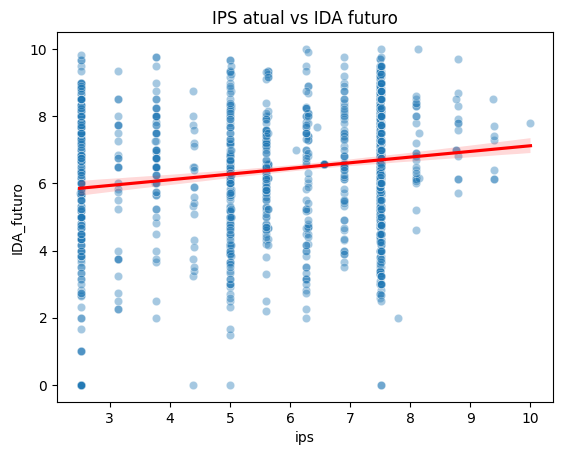

,ips,IDA_futuro
ips,1.000000,0.175503
IDA_futuro,0.175503,1.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df_fixa, x="ips", y="IDA_futuro", alpha=0.4)
sns.regplot(data=df_fixa, x="ips", y="IDA_futuro", scatter=False, color="red")
plt.title("IPS atual vs IDA futuro")
plt.show()

df_fixa[["ips","IDA_futuro"]].corr()


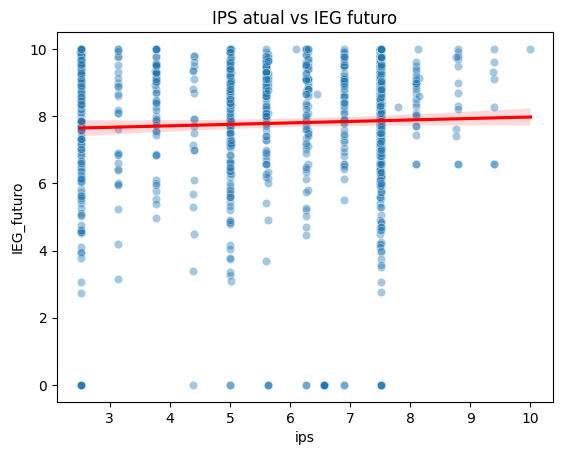

,ips,IEG_futuro
ips,1.000000,0.033927
IEG_futuro,0.033927,1.000000


In [ ]:
sns.scatterplot(data=df_fixa, x="ips", y="IEG_futuro", alpha=0.4)
sns.regplot(data=df_fixa, x="ips", y="IEG_futuro", scatter=False, color="red")
plt.title("IPS atual vs IEG futuro")
plt.show()

df_fixa[["ips","IEG_futuro"]].corr()


In [ ]:
df_fixa["queda_ida"] = df_fixa["IDA_futuro"] - df_fixa["ida"]
df_fixa["queda_ieg"] = df_fixa["IEG_futuro"] - df_fixa["ieg"]


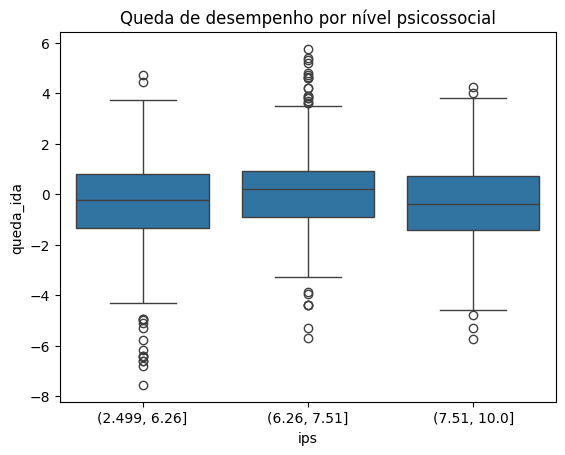

In [ ]:
sns.boxplot(data=df_fixa, x=pd.qcut(df_fixa["ips"],3), y="queda_ida")
plt.title("Queda de desempenho por nível psicossocial")
plt.show()


In [ ]:
risco_psico = df_fixa[
    (df_fixa["ips"] < df_fixa["ips"].quantile(0.25)) &
    (df_fixa["queda_ida"] < 0)
]

# Usando id_col para evitar o KeyError
risco_psico[id_col].nunique()

241

A análise longitudinal indica que o indicador psicossocial (IPS) apresenta relação antecipatória com o desempenho acadêmico e o engajamento. Alunos com níveis mais baixos de IPS tendem a apresentar maior probabilidade de queda posterior no IDA e no IEG. Os resultados sugerem que alterações psicossociais antecedem a piora acadêmica, funcionando como sinal precoce de risco educacional. Dessa forma, o IPS pode ser utilizado como indicador de alerta para intervenções preventivas antes da ocorrência de perda de aprendizagem ou desengajamento.


# 6 Aspectos psicopedagógicos (IPP)

As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

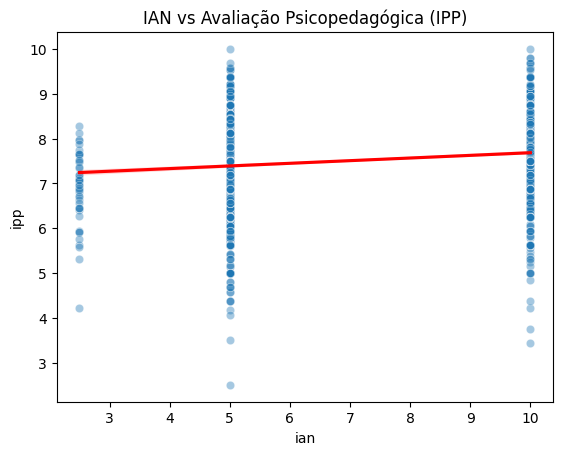

,ian,ipp
ian,1.000000,0.181171
ipp,0.181171,1.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df_fixa, x="ian", y="ipp", alpha=0.4)
sns.regplot(data=df_fixa, x="ian", y="ipp", scatter=False, color="red")
plt.title("IAN vs Avaliação Psicopedagógica (IPP)")
plt.show()

df_fixa[["ian","ipp"]].corr()


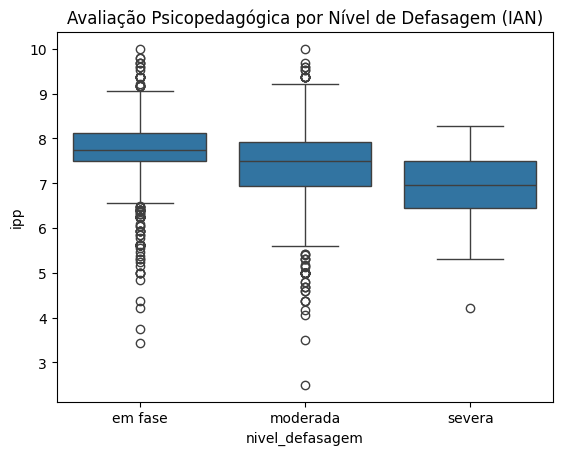

In [ ]:
sns.boxplot(data=df_fixa, x="nivel_defasagem", y="ipp",
            order=["em fase","moderada","severa"])
plt.title("Avaliação Psicopedagógica por Nível de Defasagem (IAN)")
plt.show()


In [ ]:
df_fixa["nivel_ipp"] = pd.qcut(df_fixa["ipp"],3,
                               labels=["Baixo","Médio","Alto"])


In [ ]:
pd.crosstab(df_fixa["nivel_defasagem"],
            df_fixa["nivel_ipp"],
            normalize="index")*100


nivel_ipp,Baixo,Médio,Alto
nivel_defasagem,,,
em fase,22.859270,40.357409,36.783321
moderada,42.935445,30.267966,26.796590
severa,68.888889,20.000000,11.111111


In [ ]:
falso_positivo = df_fixa[
    (df_fixa["nivel_defasagem"]=="Defasagem Severa") &
    (df_fixa["nivel_ipp"]=="Alto")
]


In [ ]:
falso_negativo = df_fixa[
    (df_fixa["nivel_defasagem"]=="Adequado") &
    (df_fixa["nivel_ipp"]=="Baixo")
]


In [ ]:
from sklearn.metrics import cohen_kappa_score

cohen_kappa_score(df_fixa["nivel_defasagem"], df_fixa["nivel_ipp"])


np.float64(0.0)

# 7 Ponto de virada (IPV)

Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?

count    3030.000000
mean        7.518471
std         1.060543
min         2.500000
25%         6.890000
50%         7.500000
75%         8.222000
max        10.000000
Name: ipv, dtype: float64


<Axes: xlabel='ipv', ylabel='Count'>

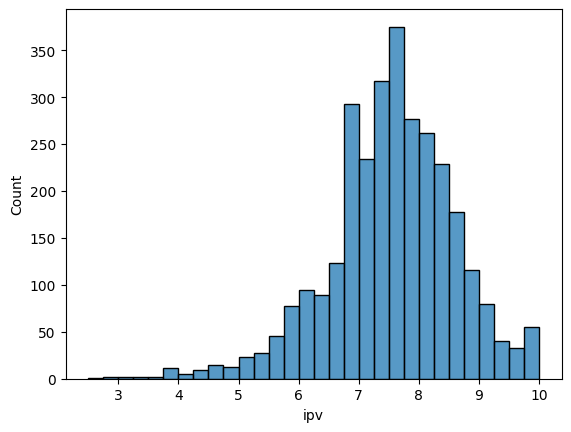

In [ ]:
print(df_fixa["ipv"].describe())
sns.histplot(df_fixa["ipv"], bins=30)


In [ ]:
df_fixa[["ipv","ida","ieg","ips","ipp"]].corr()["ipv"].sort_values(ascending=False)


,ipv
ipv,1.000000
ipp,0.597770
ida,0.549771
ieg,0.483146
ips,-0.091714


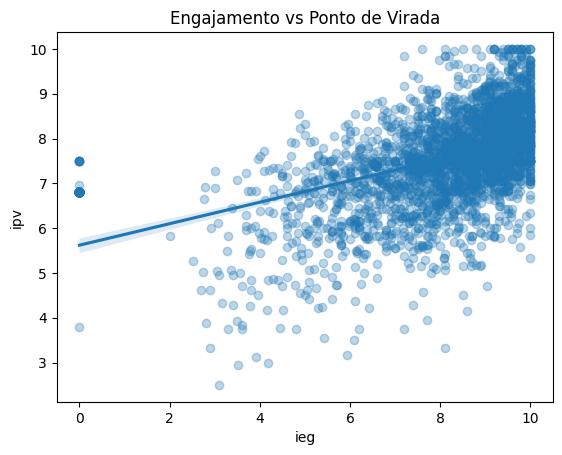

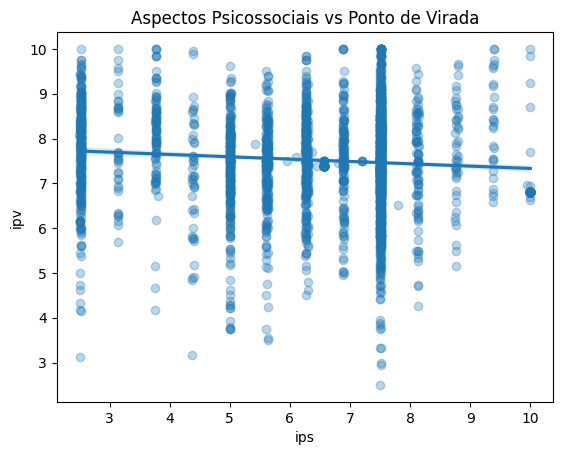

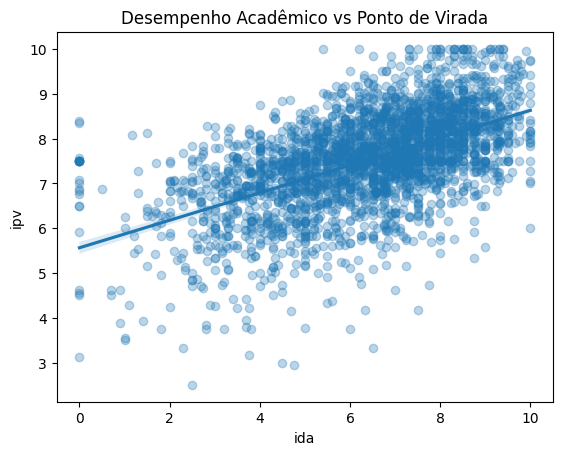

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(data=df_fixa, x="ieg", y="ipv", scatter_kws={"alpha":0.3})
plt.title("Engajamento vs Ponto de Virada")
plt.show()

sns.regplot(data=df_fixa, x="ips", y="ipv", scatter_kws={"alpha":0.3})
plt.title("Aspectos Psicossociais vs Ponto de Virada")
plt.show()

sns.regplot(data=df_fixa, x="ida", y="ipv", scatter_kws={"alpha":0.3})
plt.title("Desempenho Acadêmico vs Ponto de Virada")
plt.show()


In [ ]:
df_fixa = df_fixa.sort_values([id_col, "ano"])
df_fixa["IPV_futuro"] = df_fixa.groupby(id_col)["ipv"].shift(-1)

In [ ]:
df_fixa[["ieg","ips","ida","ipp","IPV_futuro"]].corr()["IPV_futuro"].sort_values(ascending=False)


,IPV_futuro
IPV_futuro,1.000000
ida,0.355821
ipp,0.348983
ieg,0.283206
ips,0.206522


In [ ]:
import statsmodels.api as sm

X = df_fixa[["ida","ieg","ips","ipp"]]
X = sm.add_constant(X)

y = df_fixa["ipv"]

modelo = sm.OLS(y, X, missing="drop").fit()
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:                    ipv   R-squared:                       0.536
Model:                            OLS   Adj. R-squared:                  0.536
Method:                 Least Squares   F-statistic:                     875.1
Date:                Tue, 24 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:30:29   Log-Likelihood:                -3312.3
No. Observations:                3030   AIC:                             6635.
Df Residuals:                    3025   BIC:                             6665.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.6173      0.131     12.301      0.0

A análise indica que o ponto de virada (IPV) não é explicado por um único fator, mas por um conjunto de comportamentos. O engajamento (IEG) apresenta forte relação antecedente com o IPV, sugerindo que o aumento da participação nas atividades precede mudanças positivas na trajetória do aluno. Aspectos psicossociais (IPS) também mostram influência relevante, indicando que melhorias emocionais e sociais favorecem a evolução acadêmica. O desempenho acadêmico (IDA) aparece mais como consequência desse processo do que como fator inicial. Assim, o ponto de virada parece ocorrer quando há combinação de suporte emocional e aumento do engajamento, culminando posteriormente em melhora acadêmica.



# 8 Multidimensionalidade dos indicadores

Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

count    3030.000000
mean        7.249311
std         0.966498
min         3.032000
25%         6.719938
50%         7.305810
75%         7.946847
max         9.531325
Name: inde, dtype: float64


<Axes: xlabel='inde', ylabel='Count'>

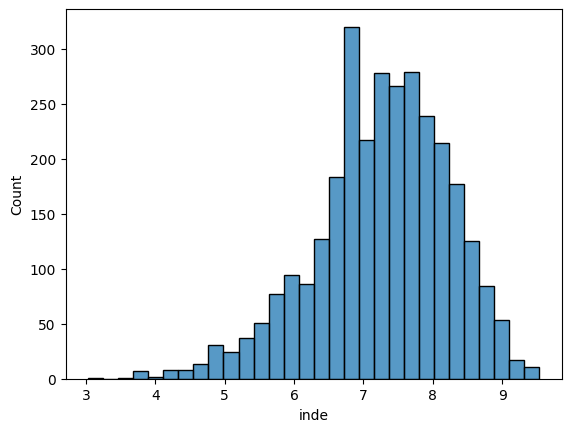

In [ ]:
print(df_fixa["inde"].describe())
sns.histplot(df_fixa["inde"], bins=30)


In [ ]:
df_fixa[["inde","ida","ieg","ips","ipp"]].corr()["inde"].sort_values(ascending=False)


,inde
inde,1.000000
ida,0.777926
ieg,0.598343
ipp,0.581041
ips,0.147868


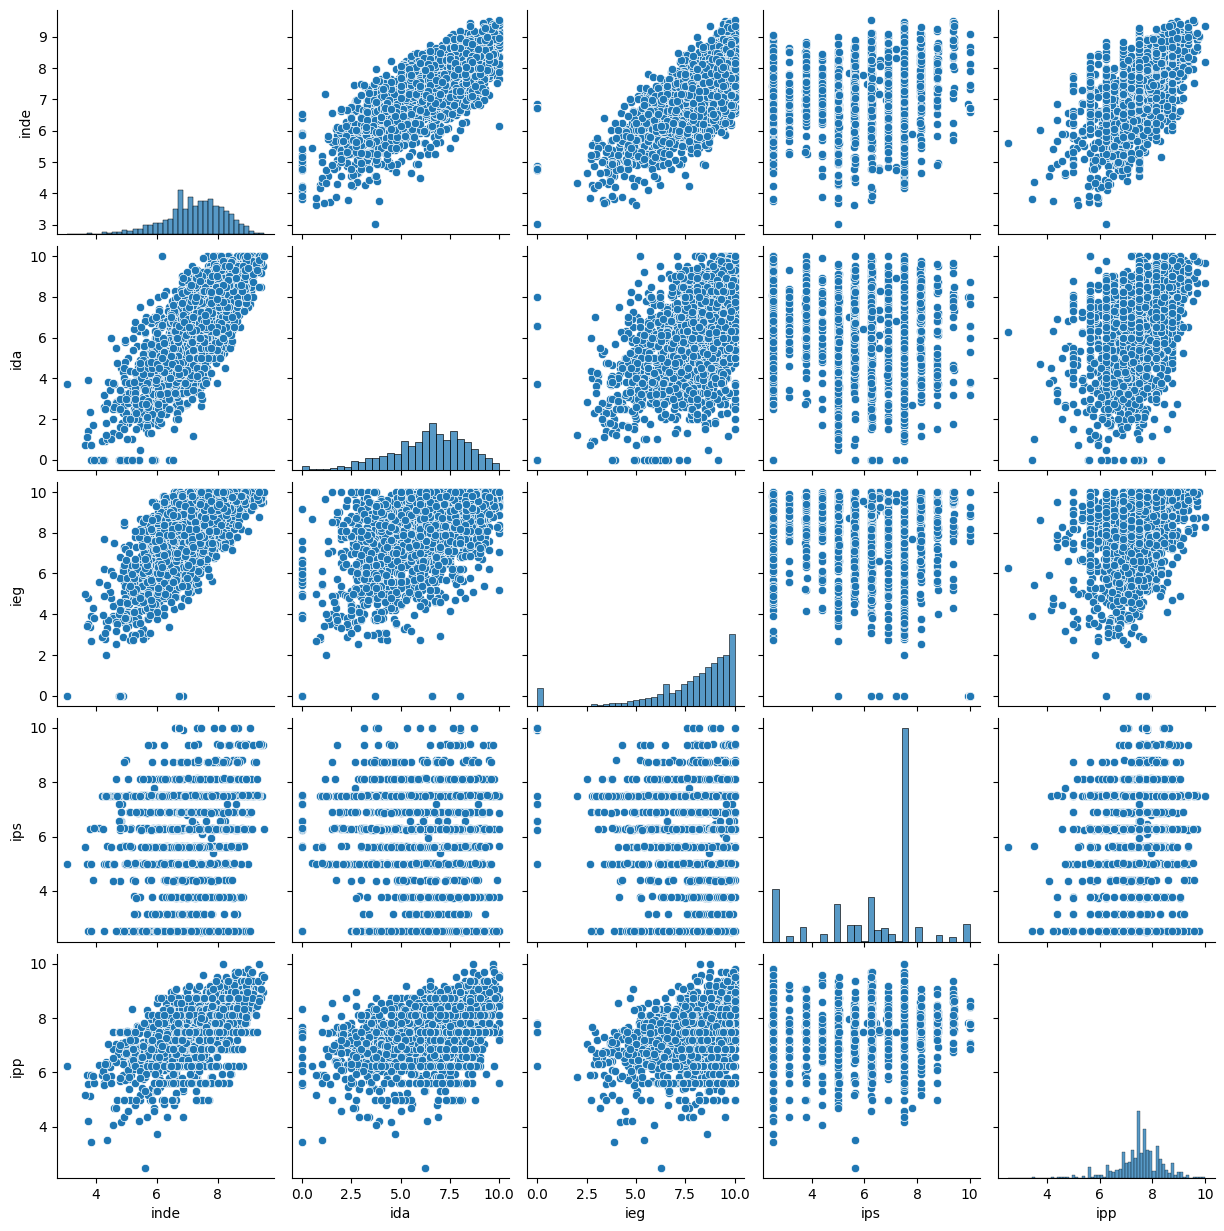

In [ ]:
import seaborn as sns

sns.pairplot(df_fixa[["inde","ida","ieg","ips","ipp"]])


In [ ]:
import statsmodels.api as sm

X = df_fixa[["ida","ieg","ips","ipp"]]
X = sm.add_constant(X)

y = df_fixa["inde"]

modelo = sm.OLS(y, X, missing="drop").fit()
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:                   inde   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     3539.
Date:                Tue, 24 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:31:30   Log-Likelihood:                -1564.3
No. Observations:                3030   AIC:                             3139.
Df Residuals:                    3025   BIC:                             3169.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1608      0.074     15.720      0.0

In [ ]:
dados_modelo = df_fixa[["ida","ieg","ips","ipp", "inde"]].dropna()
y = dados_modelo["inde"]
X = dados_modelo[["ida","ieg","ips","ipp"]]

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

import statsmodels.api as sm

X_scaled = sm.add_constant(X_scaled)
modelo = sm.OLS(y, X_scaled).fit()
print(modelo.summary())



                            OLS Regression Results                            
Dep. Variable:                   inde   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     3539.
Date:                Tue, 24 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:31:31   Log-Likelihood:                -1564.3
No. Observations:                3030   AIC:                             3139.
Df Residuals:                    3025   BIC:                             3169.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.2493      0.007    983.284      0.0

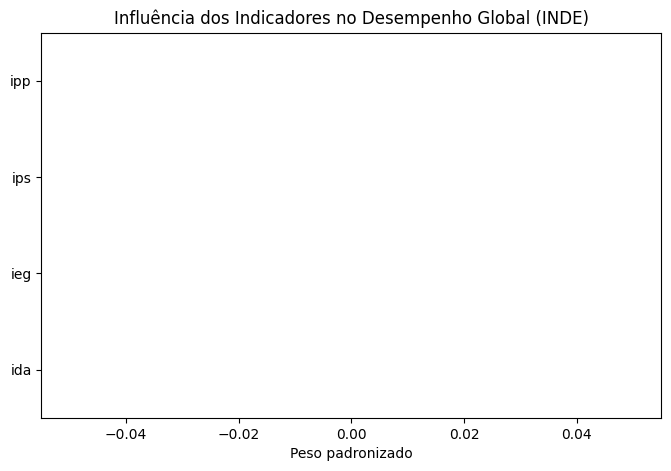

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importancia = pd.Series(
    modelo.params[1:],
    index=["ida","ieg","ips","ipp"]
)

importancia.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Influência dos Indicadores no Desempenho Global (INDE)")
plt.xlabel("Peso padronizado")
plt.show()


In [ ]:
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                   inde   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     3539.
Date:                Tue, 24 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:31:31   Log-Likelihood:                -1564.3
No. Observations:                3030   AIC:                             3139.
Df Residuals:                    3025   BIC:                             3169.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.2493      0.007    983.284      0.0

# 9 Previsão de risco com Machine Learning

Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem.

## Preparar os dados

In [ ]:
df = df_fixa.copy()


In [ ]:
import missingno as msno
msno.matrix(df)

In [ ]:
df.columns

## Treinar

In [ ]:
df['piorou_defasagem'].value_counts()

## pca

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Identificar colunas categóricas (texto ou booleano)
# Pulamos o ID do aluno para manter a referência
id_col = [c for c in df.columns if 'id_aluno' in c][0]
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
cat_cols = [col for col in cat_cols if col != id_col]

# 2. Aplicar Label Encoding
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print(f'Colunas transformadas: {cat_cols}')
display(df.head())

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Selecionar apenas colunas puramente numéricas para evitar o erro de conversão
columns_pca = ['fase', 'ano_ingresso', 'ipv', 'ian', 'ipp', 'matematica',
               'portugues', 'defasagem']

# 2. Criar cópia e tratar valores ausentes com a média
X_pca_input = df[columns_pca].copy()
X_pca_input = X_pca_input.fillna(X_pca_input.mean())

# 3. Normalizar os dados
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_pca_input)

# 4. Verificar o formato dos dados preparados
print(f"Colunas selecionadas: {columns_pca}")
print(f"Shape dos dados escalonados: {X_scaled_pca.shape}")
print("Tratamento de nulos e normalização concluídos com sucesso.")

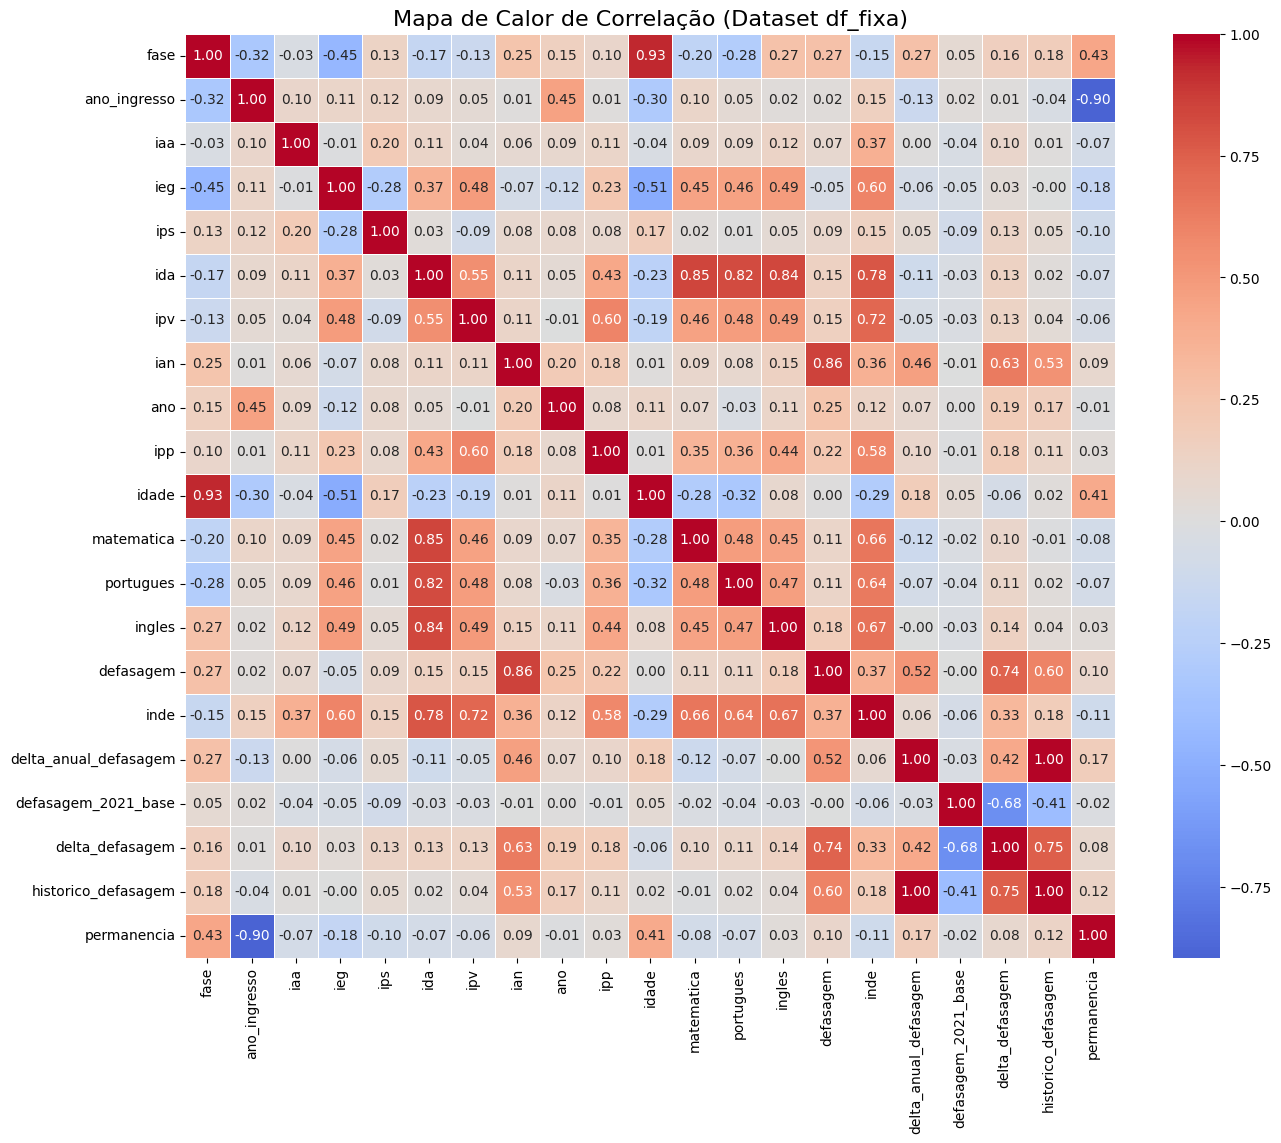

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcular a matriz de correlação usando df_fixa (que é o dataframe carregado)
# Selecionamos apenas as colunas numéricas para o cálculo
corr_matrix = df_fixa.select_dtypes(include=['number']).corr()

# 2. Configurar o estilo e gerar o heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, center=0)

plt.title('Mapa de Calor de Correlação (Dataset df_fixa)', fontsize=16)
plt.show()

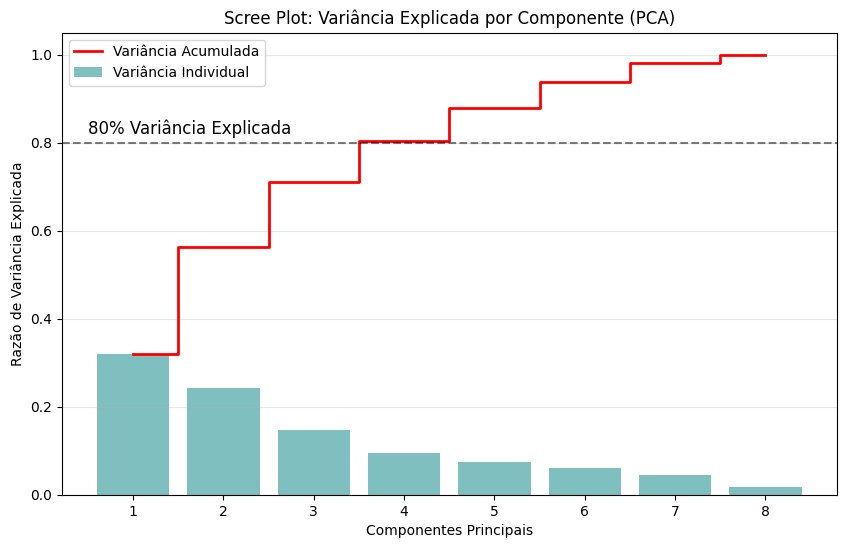

Variância Explicada Individual: [0.3206 0.2417 0.1476 0.0943 0.0738 0.0603 0.044  0.0178]
Variância Explicada Acumulada: [0.3206 0.5624 0.7099 0.8043 0.878  0.9383 0.9822 1.    ]

Número de componentes para explicar pelo menos 80% da variância: 4


In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# 1. Instanciar e ajustar o PCA para todos os componentes
pca_full = PCA()
pca_full.fit(X_scaled_pca)

# 2. Calcular variância explicada
exp_var_ratio = pca_full.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var_ratio)

# 3. Visualização (Scree Plot)
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(exp_var_ratio) + 1), exp_var_ratio, alpha=0.5, align='center', label='Variância Individual', color='teal')
plt.step(range(1, len(cum_exp_var) + 1), cum_exp_var, where='mid', label='Variância Acumulada', color='red', linewidth=2)

# Linha de referência (80%)
plt.axhline(y=0.8, color='black', linestyle='--', alpha=0.5)
plt.text(0.5, 0.82, '80% Variância Explicada', color = 'black', fontsize=12)

plt.ylabel('Razão de Variância Explicada')
plt.xlabel('Componentes Principais')
plt.title('Scree Plot: Variância Explicada por Componente (PCA)')
plt.xticks(range(1, len(exp_var_ratio) + 1))
plt.legend(loc='best')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4. Identificar número de componentes para ~80% de variância
n_components_80 = np.argmax(cum_exp_var >= 0.8) + 1
print(f"Variância Explicada Individual: {exp_var_ratio.round(4)}")
print(f"Variância Explicada Acumulada: {cum_exp_var.round(4)}")
print(f"\nNúmero de componentes para explicar pelo menos 80% da variância: {n_components_80}")

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Instanciar PCA com 2 componentes e transformar os dados
pca_2 = PCA(n_components=2)
X_pca_2d = pca_2.fit_transform(X_scaled_pca)

# 2. Criar DataFrame com as dimensões reduzidas e metadados
df_pca_viz = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
df_pca_viz['piorou_defasagem'] = df['piorou_defasagem'].values

# 3. Gráfico de Dispersão (PC1 vs PC2) colorido por Risco de Defasagem
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_pca_viz, x='PC1', y='PC2', hue='piorou_defasagem',
                palette='coolwarm', alpha=0.7, s=60)
plt.title('Dispersão dos Alunos nos Dois Primeiros Componentes Principais (PCA)')
plt.xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]:.1%} da variância)')
plt.ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]:.1%} da variância)')
plt.legend(title='Piorou Defasagem', loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# 4. Heatmap de Loadings (Cargas dos Componentes)
loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=['PC1', 'PC2'],
    index=columns_pca
)

plt.figure(figsize=(10, 8))
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Matriz de Loadings: Influência das Variáveis Originais nos Componentes')
plt.ylabel('Indicadores Originais')
plt.show()

print(f"Variância total capturada por estes 2 componentes: {pca_2.explained_variance_ratio_.sum():.2%}")

NameError: name 'df' is not defined

In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Extrair os primeiros 4 componentes principais
pca_5 = PCA(n_components=4)
X_pca_5d = pca_5.fit_transform(X_scaled_pca)

# 2. Definir a variável alvo (y)
y = df['piorou_defasagem'].values

# 3. Verificar a distribuição de classes original
print('Distribuição original das classes:')
print(pd.Series(y).value_counts(normalize=True))

# 4. Aplicar SMOTE para tratar o desequilíbrio de classes
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_pca_5d, y)

# 5. Criar DataFrame com os componentes balanceados para a fase de treino
features_cols = [f'PC{i+1}' for i in range(4)]
df_balanced = pd.DataFrame(X_balanced, columns=features_cols)
df_balanced['target'] = y_balanced

print('\nDistribuição das classes após SMOTE:')
print(pd.Series(y_balanced).value_counts(normalize=True))
print(f'\nShape final do dataset balanceado: {df_balanced.shape}')
display(df_balanced.head())

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, roc_curve
import matplotlib.pyplot as plt

# 1. Split the balanced data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

# 2. Instantiate and fit the model
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Make predictions and get probabilities
y_pred = rf_model.predict(X_test)
y_probs = rf_model.predict_proba(X_test)[:, 1]

# 4. Evaluation: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Estável', 'Piorou'])

# 5. Evaluation: ROC-AUC
auc_score = roc_auc_score(y_test, y_probs)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

disp.plot(ax=ax1, cmap='Blues')
ax1.set_title('Matriz de Confusão')

fpr, tpr, _ = roc_curve(y_test, y_probs)
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Curva ROC')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

print(f'ROC-AUC Score: {auc_score:.4f}')

In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Extrair os primeiros 5 componentes principais
pca_5 = PCA(n_components=5)
X_pca_5d = pca_5.fit_transform(X_scaled_pca)

# 2. Definir a variável alvo (y)
y = df['piorou_defasagem'].values

# 3. Verificar a distribuição de classes original
print('Distribuição original das classes:')
print(pd.Series(y).value_counts(normalize=True))

# 4. Aplicar SMOTE para tratar o desequilíbrio de classes
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_pca_5d, y)

# 5. Criar DataFrame com os componentes balanceados para a fase de treino
features_cols = [f'PC{i+1}' for i in range(5)]
df_balanced = pd.DataFrame(X_balanced, columns=features_cols)
df_balanced['target'] = y_balanced

print('\nDistribuição das classes após SMOTE:')
print(pd.Series(y_balanced).value_counts(normalize=True))
print(f'\nShape final do dataset balanceado: {df_balanced.shape}')
display(df_balanced.head())

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, roc_curve
import matplotlib.pyplot as plt

# 1. Split the balanced data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

# 2. Instantiate and fit the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Make predictions and get probabilities
y_pred = rf_model.predict(X_test)
y_probs = rf_model.predict_proba(X_test)[:, 1]

# 4. Evaluation: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Estável', 'Piorou'])

# 5. Evaluation: ROC-AUC
auc_score = roc_auc_score(y_test, y_probs)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

disp.plot(ax=ax1, cmap='Blues')
ax1.set_title('Matriz de Confusão')

fpr, tpr, _ = roc_curve(y_test, y_probs)
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Curva ROC')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

print(f'ROC-AUC Score: {auc_score:.4f}')